[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/Astroestadistica/blob/main/ITM/Main.ipynb)

---
## 1. Marco Teórico

### 1.1 El Baricentro del Sistema Solar (SSB)

El **Baricentro del Sistema Solar** (Solar System Barycenter, SSB) es el centro de masa de todo el Sistema Solar. Si denotamos la masa del cuerpo $i$ como $m_i$ y su posición como $\mathbf{r}_i$, el SSB se define como:

$$\mathbf{R}_{\rm SSB} = \frac{\sum_i m_i \, \mathbf{r}_i}{\sum_i m_i}$$

Por definición, en el **marco del SSB** el **momento lineal total** del Sistema Solar es cero:

$$\mathbf{P}_{\rm total} = \sum_i m_i \, \mathbf{v}_i = \mathbf{0}$$

Esto lo convierte en un **sistema de referencia inercial** (o casi inercial para propósitos prácticos), lo que significa que las leyes de Newton se aplican directamente sin términos de arrastre ficticios.

| Marco de referencia | Origen | Inercial | Usado por |
|---|---|---|---|
| **SSB eclíptico J2000** | Baricentro del SS | Sí | JPL DE441, SPICE |
| Heliocéntrico eclíptico J2000 | Centro del Sol | $\approx$ Sí (el Sol oscila ~0.01 AU) | Astronomía clásica |
| Geocéntrico | Centro de la Tierra | No (acelerado) | Satélites, observaciones |


### 1.2 El eje eclíptico J2000

Las posiciones y velocidades en el SSB se expresan en el sistema de coordenadas **eclíptico J2000**:
- **Eje X**: apunta hacia el equinoccio vernal del año 2000.0.
- **Eje Z**: perpendicular al plano de la eclíptica (plano de la órbita terrestre).
- **Eje Y**: completa la base derecha $\hat{z} = \hat{x} \times \hat{y}$.

Este es el sistema que usa JPL Horizons por defecto al pedir vectores de estado (`COORD_TYPE=2`).

---

### 1.3 Vectores de Estado: Posición y Velocidad

El **vector de estado** de un cuerpo en el SSB tiene 6 componentes:

$$\mathbf{y}_i = (x_i, y_i, z_i, \dot{x}_i, \dot{y}_i, \dot{z}_i) = (\mathbf{r}_i, \mathbf{v}_i)$$

donde:
- $(x_i, y_i, z_i)$ es la posición en Unidades Astronómicas (UA).
- $(\dot{x}_i, \dot{y}_i, \dot{z}_i)$ es la velocidad en UA/día.

JPL Horizons proporciona estos datos para cualquier cuerpo del Sistema Solar a partir de las **efemérides DE441** (integración numérica de alta precisión).

---

### 1.4 El Parámetro Gravitacional $\mu = GM$

La constante gravitacional universal $G = 6.674 \times 10^{-11}$ m³ kg⁻¹ s⁻² se conoce con una precisión relativa de ~22 ppm, mientras que el **parámetro gravitacional** $\mu_i = GM_i$ se conoce con muchísima mayor precisión (hasta 11 dígitos significativos) mediante observaciones orbitales de naves espaciales.

Por esta razón, en astrodinámica se trabaja directamente con $\mu$ en lugar de $G$ y $M$ por separado:

| Cuerpo | $\mu = GM$ (m³/s²) | $\mu$ (UA³/día²) | $m/M_\odot$ |
|--------|---------------------|------------------|---------------|
| **Sol** | $1.32712 \times 10^{20}$ | $2.9592 \times 10^{-4}$ | $1.0$ |
| **Tierra** | $3.9860 \times 10^{14}$ | $8.8878 \times 10^{-10}$ | $3.003 \times 10^{-6}$ |
| **Luna** | $4.9048 \times 10^{12}$ | $1.0931 \times 10^{-11}$ | $3.694 \times 10^{-8}$ |
| **Apophis** | $\approx 1.8 \times 10^{0}$ | $\approx 4 \times 10^{-24}$ | $\approx 1.4 \times 10^{-20}$ |

---

### 1.5 El Problema de N-Cuerpos: Ecuaciones de Movimiento

Para un sistema de $N$ cuerpos con masas $m_i$ y posiciones $\mathbf{r}_i$ respecto al SSB, las ecuaciones de movimiento de Newton son:

$$\boxed{\ddot{\mathbf{r}}_i = \sum_{j \neq i} \frac{G m_j (\mathbf{r}_j - \mathbf{r}_i)}{|\mathbf{r}_j - \mathbf{r}_i|^3}}$$

En nuestra simulación tenemos $N = 4$ cuerpos: Sol, Tierra, Luna y Apophis. Esto nos da un sistema de $4 \times 3 = 12$ EDOs de segundo orden, o equivalentemente $24$ EDOs de primer orden.

**Constantes de movimiento:**
- Energía mecánica total: $E = \frac{1}{2}\sum_i m_i v_i^2 - \sum_{i<j} \frac{G m_i m_j}{|\mathbf{r}_i - \mathbf{r}_j|}$
- Momento lineal total: $\mathbf{P} = \sum_i m_i \mathbf{v}_i = \mathbf{0}$ (en el SSB)
- Momento angular total: $\mathbf{L} = \sum_i m_i (\mathbf{r}_i \times \mathbf{v}_i)$



In [52]:
!pip install celluloid astropy pymcel -q

In [53]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
import pandas as pd
import rebound
import warnings
warnings.filterwarnings('ignore')

In [54]:
# Constantes de conversión
AU_m   = pc.constantes.au      # 1 UA en metros
day_s  = pc.constantes.día     # 1 día en segundos
yr_d   = pc.constantes.yr / pc.constantes.día  # 1 año en días
G_SI   = pc.constantes.G       # Constante gravitacional [m^3 kg^-1 s^-2]
c_luz  = pc.constantes.c       # Velocidad de la luz [m/s]

# Factor de conversión de mu: m^3/s^2 -> UA^3/día^2
fac_mu = day_s**2 / AU_m**3

In [55]:
# Constantes gravitacionales (SI) m^3/s^2
mu_sun_SI      = pc.constantes.mu_sun
mu_mercury_SI  = pc.constantes.mu_mercury
mu_venus_SI    = pc.constantes.mu_venus
mu_earth_SI    = pc.constantes.mu_earth
mu_moon_SI     = pc.constantes.mu_moon
mu_mars_SI     = pc.constantes.mu_mars
mu_jupiter_SI  = pc.constantes.mu_jupiter
mu_saturn_SI   = pc.constantes.mu_saturn
mu_uranus_SI   = pc.constantes.mu_uranus
mu_neptune_SI  = pc.constantes.mu_neptune

m_apophis      = 2.7e10                          # kg
mu_apophis_SI  = G_SI * m_apophis                # m^3/s^2

# Construcción del DataFrame
datos_mu = [
    ('Sol',       mu_sun_SI,     mu_sun_SI * fac_mu,     1.0),
    ('Mercurio',  mu_mercury_SI, mu_mercury_SI * fac_mu, mu_mercury_SI / mu_sun_SI),
    ('Venus',     mu_venus_SI,   mu_venus_SI * fac_mu,   mu_venus_SI / mu_sun_SI),
    ('Tierra',    mu_earth_SI,   mu_earth_SI * fac_mu,   mu_earth_SI / mu_sun_SI),
    ('Luna',      mu_moon_SI,    mu_moon_SI * fac_mu,    mu_moon_SI / mu_sun_SI),
    ('Marte',     mu_mars_SI,    mu_mars_SI * fac_mu,    mu_mars_SI / mu_sun_SI),
    ('Jupiter',   mu_jupiter_SI, mu_jupiter_SI * fac_mu, mu_jupiter_SI / mu_sun_SI),
    ('Saturno',   mu_saturn_SI,  mu_saturn_SI * fac_mu,  mu_saturn_SI / mu_sun_SI),
    ('Urano',     mu_uranus_SI,  mu_uranus_SI * fac_mu,  mu_uranus_SI / mu_sun_SI),
    ('Neptuno',   mu_neptune_SI, mu_neptune_SI * fac_mu, mu_neptune_SI / mu_sun_SI),
    ('Apophis',   mu_apophis_SI, mu_apophis_SI * fac_mu, mu_apophis_SI / mu_sun_SI),
]

cuerpos_mu = pd.DataFrame(datos_mu, columns=['Cuerpo', 'mu (m^3/s^2)', 'mu (UA^3/d^2)', 'm/M_sol'])
cuerpos_mu

,Cuerpo,mu (m^3/s^2),mu (UA^3/d^2),m/M_sol
0,Sol,1.327124e+20,2.959122e-04,1.000000e+00
1,Mercurio,2.203187e+13,4.912500e-11,1.660121e-07
2,Venus,3.248586e+14,7.243452e-10,2.447838e-06
3,Tierra,3.986004e+14,8.887692e-10,3.003490e-06
4,Luna,4.902800e+12,1.093189e-11,3.694303e-08
5,Marte,4.282838e+13,9.549549e-11,3.227156e-07
6,Jupiter,1.267128e+17,2.825346e-07,9.547919e-04
7,Saturno,3.794058e+16,8.459706e-08,2.858857e-04
8,Urano,5.794556e+15,1.292027e-08,4.366250e-05
9,Neptuno,6.836527e+15,1.524357e-08,5.151384e-05


In [56]:
#epochs_ini = {'start': '2026-04-11', 'stop': '2026-04-12', 'step': '1d'}
epochs_ini = "2029-01-01"

In [57]:
def Estados(cuerpos, propiedades, epochs):
    VectorEstadoSI = {}
    for nombre, id in cuerpos:
        _, _, salida = pc.consulta_horizons(
            id=id,
            location="@0",
            datos="vectors",
            propiedades=propiedades,
            epochs=epochs,
        )
        # Convertir la salida a un vector único [x, y, z, vx, vy, vz]
        VectorEstadoSI[nombre] = np.array(salida, dtype=float).reshape(-1)
    return VectorEstadoSI

def UnidadesCanonicas(EstadosSI, MasasSI, UL=1.495978707e11, UM=1.98847e30):
    UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)
    vel_unit = UL / UT

    EstadoCanonico = {}
    for nombre, vec in EstadosSI.items():
        # Asegurarse de que el vector tenga 6 elementos: [x, y, z, vx, vy, vz]
        if len(vec) != 6:
            raise ValueError(f"El vector de estado para {nombre} debe tener 6 elementos: [x, y, z, vx, vy, vz]")
        x, y, z, vx, vy, vz = vec
        EstadoCanonico[nombre] = np.array([
            x / UL,
            y / UL,
            z / UL,
            vx / vel_unit,
            vy / vel_unit,
            vz / vel_unit,
        ])

    MasasCanonico = {nombre: MasasSI[nombre] / UM for nombre in MasasSI}
    return EstadoCanonico, MasasCanonico, UL, UM, UT, Gc

In [58]:
CUERPOS = [
    ('Sol',       '10',    'majorbody', mu_sun_SI),
    ('Mercurio',  '199',   'majorbody', mu_mercury_SI),
    ('Venus',     '299',   'majorbody', mu_venus_SI),
    ('Tierra',    '399',   'majorbody', mu_earth_SI),
    ('Luna',      '301',   'majorbody', mu_moon_SI),
    ('Marte',     '499',   'majorbody', mu_mars_SI),
    ('Jupiter',   '599',   'majorbody', mu_jupiter_SI),
    ('Saturno',   '699',   'majorbody', mu_saturn_SI),
    ('Urano',     '799',   'majorbody', mu_uranus_SI),
    ('Neptuno',   '899',   'majorbody', mu_neptune_SI),
    ('Apophis',   '99942', 'smallbody', mu_apophis_SI),
]

epochs_ini = '2029-01-01'  # Solo una fecha

estados_ini = {}

for nombre, horizons_id, id_type, mu in CUERPOS:
    print(f'Consultando Horizons para {nombre} (ID={horizons_id})...')
    try:
        # pc.consulta_horizons devuelve una tupla: (tabla, tiempo_jd, vector_estado)
        tabla, tiempo_jd, vector_estado = pc.consulta_horizons(
            id=horizons_id,
            location='@0',
            epochs=epochs_ini,
            datos='vectors',
        )
        # El vector de estado ya está en el formato [x, y, z, vx, vy, vz]
        estados_ini[nombre] = vector_estado
    except Exception as e:
        print(f"Error al consultar {nombre}: {e}")

# Verificar el resultado
for nombre, vector in estados_ini.items():
    print(f"{nombre}: {vector}")

Consultando Horizons para Sol (ID=10)...
Consultando Horizons para Mercurio (ID=199)...
Consultando Horizons para Venus (ID=299)...
Consultando Horizons para Tierra (ID=399)...
Consultando Horizons para Luna (ID=301)...
Consultando Horizons para Marte (ID=499)...
Consultando Horizons para Jupiter (ID=599)...
Consultando Horizons para Saturno (ID=699)...
Consultando Horizons para Urano (ID=799)...
Consultando Horizons para Neptuno (ID=899)...
Consultando Horizons para Apophis (ID=99942)...
Sol: [ 1.84485534e+08 -2.06688685e+08  4.68177882e+06 -7.07905228e-01
  9.08755465e+00 -1.59729726e-02]
Mercurio: [ 4.57696300e+10  1.90969458e+10 -2.59830871e+09 -2.84706363e+04
  4.70237667e+04  6.45337759e+03]
Venus: [-6.44802810e+10 -8.71084482e+10  2.54112934e+09  2.78505275e+04
 -2.10609194e+04 -1.89666010e+03]
Tierra: [-2.64894151e+10  1.44454539e+11 -4.75199991e+06 -2.97678141e+04
 -5.49983655e+03  1.68906951e+00]
Luna: [-2.65819383e+10  1.44819466e+11 -5.17747475e+06 -3.07691630e+04
 -5.79759

In [59]:
print(f'Época inicial de la simulación: {epochs_ini}')
print(f'Cuerpos incluidos en la simulación: {[c[0] for c in CUERPOS]}')

Época inicial de la simulación: 2029-01-01
Cuerpos incluidos en la simulación: ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Neptuno', 'Apophis']


In [60]:
estados_ini

{'Sol': array([ 1.84485534e+08, -2.06688685e+08,  4.68177882e+06, -7.07905228e-01,
         9.08755465e+00, -1.59729726e-02]),
 'Mercurio': array([ 4.57696300e+10,  1.90969458e+10, -2.59830871e+09, -2.84706363e+04,
         4.70237667e+04,  6.45337759e+03]),
 'Venus': array([-6.44802810e+10, -8.71084482e+10,  2.54112934e+09,  2.78505275e+04,
        -2.10609194e+04, -1.89666010e+03]),
 'Tierra': array([-2.64894151e+10,  1.44454539e+11, -4.75199991e+06, -2.97678141e+04,
        -5.49983655e+03,  1.68906951e+00]),
 'Luna': array([-2.65819383e+10,  1.44819466e+11, -5.17747475e+06, -3.07691630e+04,
        -5.79759026e+03, -9.47705451e+01]),
 'Marte': array([-2.10696773e+11,  1.31915252e+11,  7.94414962e+09, -1.19557872e+04,
        -1.84541894e+04, -9.39140078e+01]),
 'Jupiter': array([-7.89580901e+11, -2.04160295e+11,  1.85226430e+10,  3.11566176e+03,
        -1.20434471e+04, -1.96230337e+01]),
 'Saturno': array([ 1.05942345e+12,  8.77603409e+11, -5.74447089e+10, -6.68527771e+03,
       

# Construcción del sistema en pymcel

In [61]:
#  Construcción del sistema para pymcel

sistema = []
nombres_sim = []  # para etiquetas

for nombre, horizons_id, id_type, mu_si in CUERPOS:
    data = estados_ini[nombre]

    # Obtener mu en UA^3/d^2 del DataFrame cuerpos_mu
    mu_ua_day = cuerpos_mu.loc[cuerpos_mu['Cuerpo'] == nombre, 'mu (UA^3/d^2)'].iloc[0]

    r_au = np.array(data[:3]) / AU_m
    v_au_day = np.array(data[3:]) * day_s / AU_m

    sistema.append(dict(
        m = mu_ua_day,   # En UA^3/d^2 (G=1 canónico)
        r = r_au.tolist(), # AU
        v = v_au_day.tolist(), # AU/day
    ))
    nombres_sim.append(nombre)

# Imprimir configuración
print('Sistema de simulación:')
print(f'{"Cuerpo":<10} {"μ (UA^3/d^2)":>16} {"r [UA]":<40} {"v [UA/d]"}')
print('-'*100)
for i, (cuerpo, s) in enumerate(zip(nombres_sim, sistema)):
    rv = np.array(s['r'])
    vv = np.array(s['v'])
    print(f'{cuerpo:<10} {s["m"]:>16.4e}  [{rv[0]:+.4f}, {rv[1]:+.4f}, {rv[2]:+.5f}]  '
          f'[{vv[0]:+.6f}, {vv[1]:+.6f}, {vv[2]:+.6f}]')


Sistema de simulación:
Cuerpo         μ (UA^3/d^2) r [UA]                                   v [UA/d]
----------------------------------------------------------------------------------------------------
Sol              2.9591e-04  [+0.0012, -0.0014, +0.00003]  [-0.000000, +0.000005, -0.000000]
Mercurio         4.9125e-11  [+0.3060, +0.1277, -0.01737]  [-0.016443, +0.027158, +0.003727]
Venus            7.2435e-10  [-0.4310, -0.5823, +0.01699]  [+0.016085, -0.012164, -0.001095]
Tierra           8.8877e-10  [-0.1771, +0.9656, -0.00003]  [-0.017192, -0.003176, +0.000001]
Luna             1.0932e-11  [-0.1777, +0.9681, -0.00003]  [-0.017771, -0.003348, -0.000055]
Marte            9.5495e-11  [-1.4084, +0.8818, +0.05310]  [-0.006905, -0.010658, -0.000054]
Jupiter          2.8253e-07  [-5.2780, -1.3647, +0.12382]  [+0.001799, -0.006956, -0.000011]
Saturno          8.4597e-08  [+7.0818, +5.8664, -0.38399]  [-0.003861, +0.004286, +0.000079]
Urano            1.2920e-08  [+5.9212, +18.3564, -0.00

In [62]:
# Vector de tiempos
N_PASOS = 1000
T_FINAL = 2*365.0    # días
ts = np.linspace(0.0, T_FINAL, N_PASOS)

# Integración de N-Cuerpos con pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

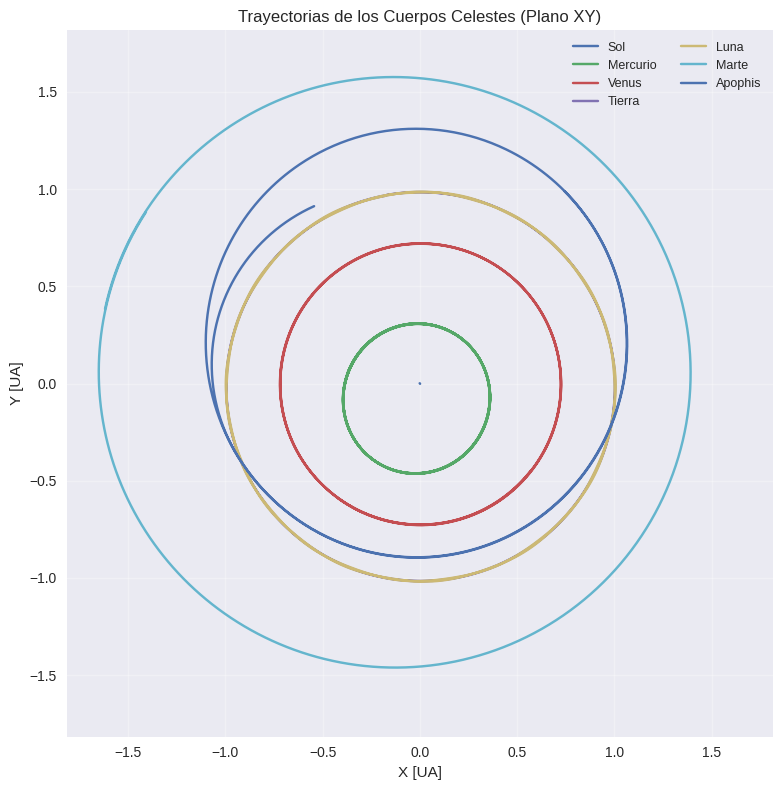

In [63]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10, 8))


max_coord = 0


bodies_to_plot = nombres_sim[:nombres_sim.index('Marte') + 1]
if 'Apophis' in nombres_sim:
    bodies_to_plot.append('Apophis')

for nombre in bodies_to_plot:
    i = nombres_sim.index(nombre) # Get the original index from the full list
    r_plot_x = rs[i, :, 0]
    r_plot_y = rs[i, :, 1]
    plt.plot(r_plot_x, r_plot_y, label=nombre)

    max_x = np.max(np.abs(r_plot_x))
    max_y = np.max(np.abs(r_plot_y))
    max_coord = max(max_coord, max_x, max_y)

plot_limit = max_coord * 1.1
plt.xlim(-plot_limit, plot_limit)
plt.ylim(-plot_limit, plot_limit)

plt.xlabel('X [UA]')
plt.ylabel('Y [UA]')
plt.title('Trayectorias de los Cuerpos Celestes (Plano XY)')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

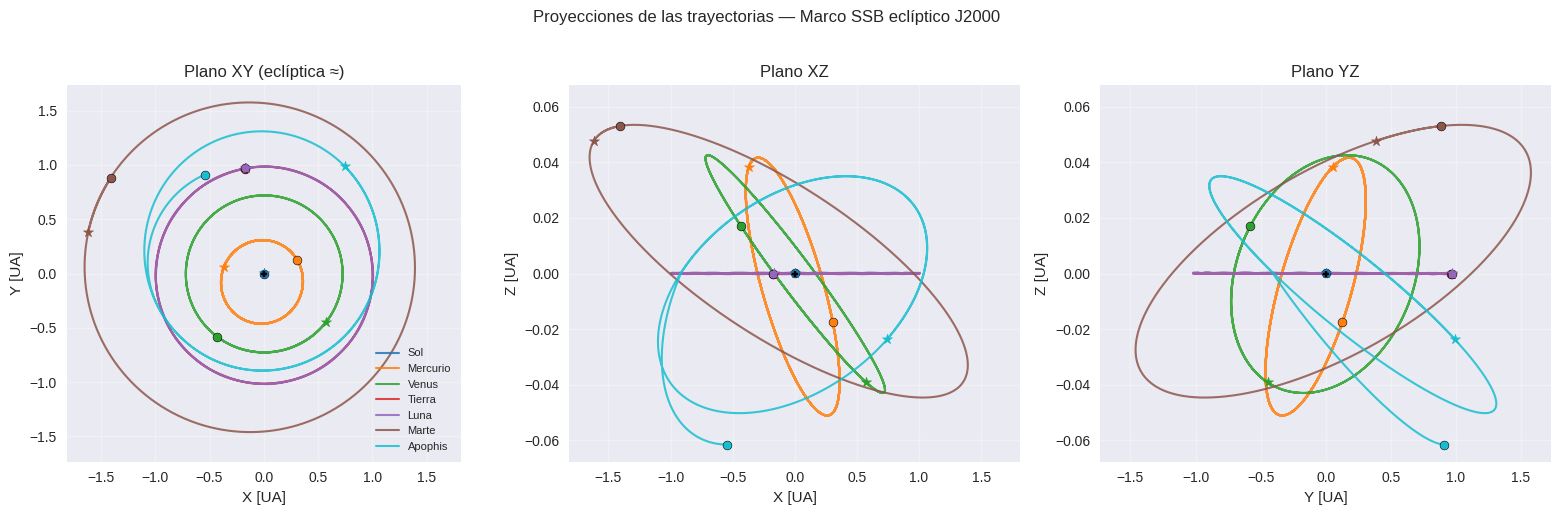

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

planos = [
    (0, 1, 'X [UA]', 'Y [UA]', 'Plano XY (eclíptica ≈)'),
    (0, 2, 'X [UA]', 'Z [UA]', 'Plano XZ'),
    (1, 2, 'Y [UA]', 'Z [UA]', 'Plano YZ'),
]

colores = {nombre: plt.cm.tab10(i) for i, nombre in enumerate(nombres_sim)}


bodies_to_plot = nombres_sim[:nombres_sim.index('Marte') + 1]
if 'Apophis' in nombres_sim:
    bodies_to_plot.append('Apophis')

for ax, (ix, iy, xl, yl, titulo) in zip(axes, planos):
    max_val_x_current_plane = 0
    max_val_y_current_plane = 0

    for nombre in bodies_to_plot:
        i = nombres_sim.index(nombre)
        tray = rs[i]
        c = colores[nombre]
        ax.plot(tray[:, ix], tray[:, iy], '-', color=c, linewidth=1.5,
                label=nombre, alpha=0.85)

        ax.scatter(tray[0, ix], tray[0, iy], s=40, color=c,
                   edgecolors='k', linewidths=0.4, zorder=5)

        ax.scatter(tray[-1, ix], tray[-1, iy], s=60, color=c, marker='*', zorder=5)


        max_val_x_current_plane = max(max_val_x_current_plane, np.max(np.abs(tray[:, ix])))
        max_val_y_current_plane = max(max_val_y_current_plane, np.max(np.abs(tray[:, iy])))

    plot_limit_x = max_val_x_current_plane * 1.1
    plot_limit_y = max_val_y_current_plane * 1.1

    ax.set_xlim(-plot_limit_x, plot_limit_x)
    ax.set_ylim(-plot_limit_y, plot_limit_y)


    ax.scatter(0, 0, s=25, color='k', marker='+', zorder=6)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(titulo)


    if titulo == 'Plano XY (eclíptica ≈)':
        ax.set_aspect('equal', adjustable='box')

    else:
        ax.set_aspect('auto', adjustable='box')

    if ax == axes[0]:
        ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Proyecciones de las trayectorias — Marco SSB eclíptico J2000', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Funciones para calcular energías

In [65]:
def calcular_energia_cinetica(vs_step, sistema):
    energia_cinetica = 0.0
    for i, body_data in enumerate(sistema):
        m_i = body_data['m']
        v_i = vs_step[i] # Velocidad del cuerpo i en este paso de tiempo
        energia_cinetica += 0.5 * m_i * np.linalg.norm(v_i)**2
    return energia_cinetica

def calcular_energia_potencial(rs_step, sistema, Gc=1.0):
    energia_potencial = 0.0
    num_cuerpos = len(sistema)
    for i in range(num_cuerpos):
        for j in range(i + 1, num_cuerpos):
            m_i = sistema[i]['m']
            m_j = sistema[j]['m']
            r_i = rs_step[i]
            r_j = rs_step[j]

            # Distancia entre los cuerpos i y j
            distancia = np.linalg.norm(r_i - r_j)

            if distancia > 0: # Evitar división por cero si los cuerpos están en la misma posición
                energia_potencial -= (Gc * m_i * m_j) / distancia
    return energia_potencial



energias_cineticas = []
energias_potenciales = []

Gc_canonical = 1.0

for t in range(N_PASOS):

    rs_t = rs[:, t, :]
    vs_t = vs[:, t, :]

    K_t = calcular_energia_cinetica(vs_t, sistema)
    energias_cineticas.append(K_t)

    U_t = calcular_energia_potencial(rs_t, sistema, Gc=Gc_canonical)
    energias_potenciales.append(U_t)

energias_cineticas = np.array(energias_cineticas)
energias_potenciales = np.array(energias_potenciales)
energias_totales = energias_cineticas + energias_potenciales

print("Energías calculadas para cada paso de tiempo.")
print(f"Energía Cinética (inicial): {energias_cineticas[0]:.4e}")
print(f"Energía Potencial (inicial): {energias_potenciales[0]:.4e}")
print(f"Energía Total (inicial): {energias_totales[0]:.4e}")

energia_total_promedio = np.mean(energias_totales)
variacion_maxima_energia = np.max(np.abs(energias_totales - energia_total_promedio)) / np.abs(energia_total_promedio)
print(f"Variación máxima relativa de la energía total: {variacion_maxima_energia:.2e}")

Energías calculadas para cada paso de tiempo.
Energía Cinética (inicial): 9.1971e-12
Energía Potencial (inicial): -1.9028e-11
Energía Total (inicial): -9.8314e-12
Variación máxima relativa de la energía total: 1.50e-08
